In [44]:
!pip install vaderSentiment rapidfuzz -q

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from rapidfuzz import fuzz, process
from scipy import stats

print('All imports OK')

All imports OK


In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
INSPECTION_CSV = '/content/drive/MyDrive/claude_workspace/inspection_results.csv'
TRIPADVISOR_CSV = '/content/drive/MyDrive/claude_workspace/trip_advisor.csv'
MATCH_THRESHOLD = 85   # fuzzy match score cutoff (0-100)

# Verify files exist
import os
print('Inspection file exists:', os.path.exists(INSPECTION_CSV))
print('TripAdvisor file exists:', os.path.exists(TRIPADVISOR_CSV))

Inspection file exists: True
TripAdvisor file exists: True


Load & clean inspection data

- Parse dates and scores
- Keep only 5 boroughs + valid grades (A/B/C)
- Collapse to one row per restaurant (latest inspection)

In [48]:
print('Loading inspection data (this may take ~30s)...')
insp = pd.read_csv(INSPECTION_CSV, engine='python', on_bad_lines='skip')
print(f'Raw inspection rows: {len(insp):,}')

insp['INSPECTION DATE'] = pd.to_datetime(insp['INSPECTION DATE'], errors='coerce')
insp['SCORE'] = pd.to_numeric(insp['SCORE'], errors='coerce')
insp['BORO'] = insp['BORO'].astype(str).str.strip().str.title()
insp['GRADE'] = insp['GRADE'].astype(str).str.strip()
insp['DBA'] = insp['DBA'].astype(str).str.strip()

valid_boros = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']
insp = insp[insp['BORO'].isin(valid_boros)].copy()
insp = insp.dropna(subset=['CAMIS', 'INSPECTION DATE', 'DBA'])
print(f'After borough/date filter: {len(insp):,}')

Loading inspection data (this may take ~30s)...
Raw inspection rows: 295,746
After borough/date filter: 295,424


In [49]:

latest = (
    insp.groupby('CAMIS')['INSPECTION DATE'].max()
    .reset_index()
    .rename(columns={'INSPECTION DATE': 'LATEST_DATE'})
)
insp_latest = insp.merge(latest, on='CAMIS')
insp_latest = insp_latest[insp_latest['INSPECTION DATE'] == insp_latest['LATEST_DATE']]


restaurant_level = (
    insp_latest.groupby('CAMIS')
    .agg(
        name=('DBA', 'first'),
        borough=('BORO', 'first'),
        cuisine=('CUISINE DESCRIPTION', 'first'),
        score=('SCORE', 'first'),
        grade=('GRADE', 'first'),
        latitude=('Latitude', 'first'),
        longitude=('Longitude', 'first'),
    )
    .reset_index()
)


restaurant_level = restaurant_level[restaurant_level['grade'].isin(['A', 'B', 'C'])].copy()
restaurant_level['name_clean'] = restaurant_level['name'].str.lower().str.strip()

print(f'Graded restaurants (A/B/C): {len(restaurant_level):,}')
print('\nGrade distribution:')
print(restaurant_level['grade'].value_counts())
print('\nBorough distribution:')
print(restaurant_level['borough'].value_counts())
restaurant_level.head()

Graded restaurants (A/B/C): 20,769

Grade distribution:
grade
A    19280
B     1366
C      123
Name: count, dtype: int64

Borough distribution:
borough
Manhattan        8204
Brooklyn         5318
Queens           4656
Bronx            1908
Staten Island     683
Name: count, dtype: int64


,CAMIS,name,borough,cuisine,score,grade,latitude,longitude,name_clean
0,30075445,MORRIS PARK BAKE SHOP,Bronx,Bakery Products/Desserts,7.0,A,40.848231,-73.855972,morris park bake shop
1,30191841,D.J. REYNOLDS,Manhattan,Irish,10.0,A,40.767326,-73.984310,d.j. reynolds
2,40356018,RIVIERA CATERERS,Brooklyn,American,10.0,A,40.579896,-73.982087,riviera caterers
3,40356483,WILKEN'S FINE FOOD,Brooklyn,Sandwiches,12.0,A,40.620112,-73.906989,wilken's fine food
4,40356731,TASTE THE TROPICS ICE CREAM,Brooklyn,Frozen Desserts,12.0,A,40.640795,-73.948488,taste the tropics ice cream


Load & clean TripAdvisor data

In [50]:
ta = pd.read_csv(TRIPADVISOR_CSV)
print(f'TripAdvisor rows: {len(ta):,}')
print('Columns:', ta.columns.tolist())

# Strip curly quotes and whitespace from review text
ta['comment_clean'] = (
    ta['Reveiw Comment'].astype(str).str.strip()
    .str.strip('"').str.strip("'")
    .str.strip('\u201c\u201d')  # smart quotes
    .str.strip()
)
ta['title_clean'] = ta['Title'].astype(str).str.lower().str.strip()

ta.head()

TripAdvisor rows: 10,397
Columns: ['Title', 'Number of review', 'Catagory', 'Reveiw Comment', 'Popular food', 'Online Order']


,Title,Number of review,Catagory,Reveiw Comment,Popular food,Online Order,comment_clean,title_clean
0,All Stars Sports Bar & Grill,21,"Bar, Pub","“The fries were terrific also, hot crisp...”",fries,Yes,"The fries were terrific also, hot crisp...",all stars sports bar & grill
1,Olio e Piu,"2,998","Italian, Pizza",“I love the food and our server Maria!”,filet mignon,Yes,I love the food and our server Maria!,olio e piu
2,Boucherie West Village,"1,465","French, Steakhouse",“The filet mignon was impeccable and the musse...,lobster,Yes,The filet mignon was impeccable and the mussel...,boucherie west village
3,Club A Steakhouse,"4,413","American, Steakhouse",“My seafood cocktail had wonderful large lump ...,cacio e pepe,Yes,My seafood cocktail had wonderful large lump c...,club a steakhouse
4,Piccola Cucina Estiatorio,403,"Italian, Sicilian",“penne al pomodoro and bucatini cacio e pepe w...,mussels,Yes,penne al pomodoro and bucatini cacio e pepe we...,piccola cucina estiatorio


VADER sentiment analysis

VADER's compound score ranges from -1 (very negative) to +1 (very positive). Suitable for short English snippets.

Sentiment distribution:
count    10397.000
mean         0.222
std          0.397
min         -0.915
25%          0.000
50%          0.226
75%          0.599
max          0.937
Name: sentiment, dtype: float64


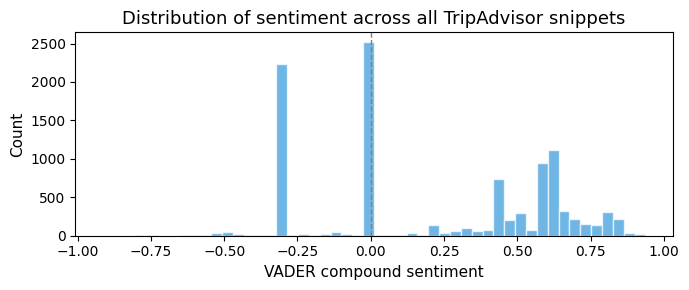

In [51]:
sia = SentimentIntensityAnalyzer()
ta['sentiment'] = ta['comment_clean'].apply(lambda x: sia.polarity_scores(x)['compound'])

print('Sentiment distribution:')
print(ta['sentiment'].describe().round(3))

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(ta['sentiment'], bins=50, color='#3498db', alpha=0.7, edgecolor='white')
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('VADER compound sentiment')
ax.set_ylabel('Count')
ax.set_title('Distribution of sentiment across all TripAdvisor snippets')
plt.tight_layout()
plt.show()

The overall sentiment distribution is heavily skewed positive (mean = 0.22), with few strongly negative reviews. This reflects TripAdvisor's selection bias toward engaging, favorable snippets — a ceiling effect that may compress sentiment differences across inspection grades in later comparisons.

Fuzzy matching

For each TripAdvisor restaurant, find the closest-matching restaurant name in the inspection data using token-sort ratio. Threshold = 85 (on 0–100 scale).

In [52]:
print(f'Matching {len(ta):,} TripAdvisor records against {len(restaurant_level):,} restaurants...')
print(f'(This takes ~2-3 minutes)')

insp_names = restaurant_level['name_clean'].tolist()
insp_lookup = restaurant_level.set_index('name_clean')

matched_rows = []
for i, ta_row in ta.iterrows():
    if i % 1000 == 0 and i > 0:
        print(f'  {i}/{len(ta)}  matched so far: {len(matched_rows)}')
    result = process.extractOne(
        ta_row['title_clean'],
        insp_names,
        scorer=fuzz.token_sort_ratio,
    )
    if result and result[1] >= MATCH_THRESHOLD:
        matched_name = result[0]
        insp_info = insp_lookup.loc[matched_name]
        if isinstance(insp_info, pd.DataFrame):
            insp_info = insp_info.iloc[0]
        matched_rows.append({
            'ta_title': ta_row['Title'],
            'insp_name': insp_info['name'],
            'match_score': result[1],
            'borough': insp_info['borough'],
            'cuisine': insp_info['cuisine'],
            'grade': insp_info['grade'],
            'insp_score': insp_info['score'],
            'sentiment': ta_row['sentiment'],
            'comment': ta_row['comment_clean'],
            'ta_category': ta_row['Catagory'],
        })

merged = pd.DataFrame(matched_rows).drop_duplicates(subset=['ta_title'])
merged = merged[merged['grade'].isin(['A', 'B', 'C'])].copy()
print(f'\n=== Matching complete ===')
print(f'Matched restaurants: {len(merged):,}')
print(f'Match rate: {len(merged) / len(ta):.1%}')
print(f'\nGrade breakdown:\n{merged["grade"].value_counts()}')
print(f'\nBorough breakdown:\n{merged["borough"].value_counts()}')

Matching 10,397 TripAdvisor records against 20,769 restaurants...
(This takes ~2-3 minutes)
  1000/10397  matched so far: 502
  2000/10397  matched so far: 961
  3000/10397  matched so far: 1430
  4000/10397  matched so far: 1875
  5000/10397  matched so far: 2327
  6000/10397  matched so far: 2748
  7000/10397  matched so far: 3186
  8000/10397  matched so far: 3661
  9000/10397  matched so far: 4068
  10000/10397  matched so far: 4331

=== Matching complete ===
Matched restaurants: 2,637
Match rate: 25.4%

Grade breakdown:
grade
A    2441
B     180
C      16
Name: count, dtype: int64

Borough breakdown:
borough
Manhattan        2094
Queens            224
Brooklyn          207
Bronx              90
Staten Island      22
Name: count, dtype: int64


In [53]:
# Show sample matches for sanity check
print('Sample matches (for quality check):')
merged[['ta_title', 'insp_name', 'match_score', 'borough', 'grade']].head(15)

Sample matches (for quality check):


,ta_title,insp_name,match_score,borough,grade
0,Olio e Piu,OLIO E PIU,100.000000,Manhattan,A
1,KOBA Korean Bbq,KOBA KOREAN BBQ,100.000000,Manhattan,A
2,Bleecker Street Pizza,BLEECKER STREET PIZZA,100.000000,Manhattan,A
3,Numero 28 Pizzeria,NUMERO 28 PIZZERIA,100.000000,Manhattan,A
4,Los Tacos No. 1,LOS TACOS NO. 1,100.000000,Manhattan,A
5,Quality Bistro,QUALITY BISTRO,100.000000,Manhattan,A
6,Bua Thai Ramen & Robata Grill,BUA THAI RAMEN & ROBATA GRILL,100.000000,Manhattan,A
7,Bagels & Schmear,BAGEL & SCHMEAR,96.774194,Manhattan,A
8,Piccola Cucina Osteria,PICCOLA CUCINA OSTERIA,100.000000,Manhattan,A
9,Loi Estiatorio,ESTIATORIO MILOS,86.666667,Manhattan,A


Analysis & Visualization

Five figures:
1. Violin plot — sentiment distribution by grade
2. Bar chart — average sentiment by grade (with statistical test)
3. Scatter — sentiment vs inspection score
4. Heatmap — borough × grade (answers teammate's question)
5. Word comparison — Grade A vs Grade B/C

In [54]:
# Shared styling
GRADE_COLORS = {'A': '#2ecc71', 'B': '#f39c12', 'C': '#e74c3c'}
GRADE_ORDER = ['A', 'B', 'C']

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

### Fig 1 — Sentiment distribution by Grade (violin + jittered strip)

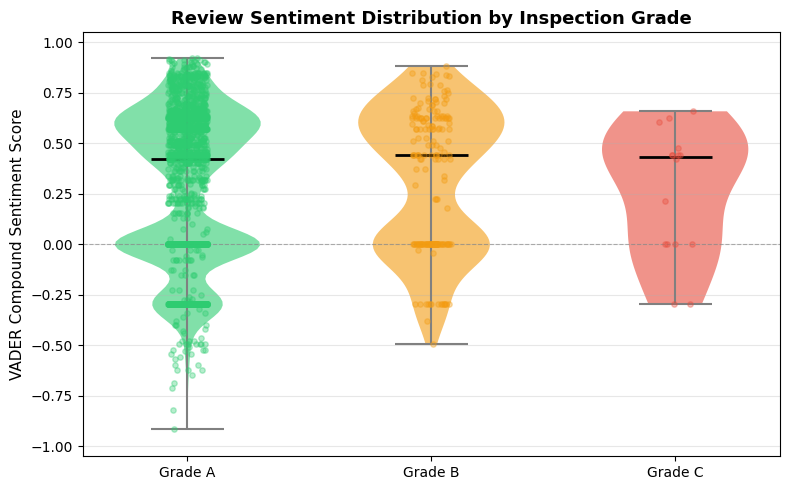

In [55]:
fig, ax = plt.subplots(figsize=(8, 5))
positions = {'A': 1, 'B': 2, 'C': 3}
violin_data = [merged[merged['grade'] == g]['sentiment'].values for g in GRADE_ORDER]

vp = ax.violinplot(violin_data, positions=[1, 2, 3], showmedians=True, widths=0.6)
for body, g in zip(vp['bodies'], GRADE_ORDER):
    body.set_facecolor(GRADE_COLORS[g])
    body.set_alpha(0.6)
vp['cmedians'].set_color('black')
vp['cmedians'].set_linewidth(2)
for part in ['cbars', 'cmins', 'cmaxes']:
    vp[part].set_color('gray')

rng = np.random.default_rng(42)
for g, pos in positions.items():
    vals = merged[merged['grade'] == g]['sentiment'].values
    jitter = rng.uniform(-0.08, 0.08, len(vals))
    ax.scatter(pos + jitter, vals, color=GRADE_COLORS[g], alpha=0.35, s=15, zorder=3)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Grade A', 'Grade B', 'Grade C'])
ax.set_ylabel('VADER Compound Sentiment Score')
ax.set_title('Review Sentiment Distribution by Inspection Grade', fontweight='bold')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_ylim(-1.05, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('q3_fig1_sentiment_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

Sentiment distributions look similar across all three grades, with medians clustering around 0.42 regardless of A, B, or C. Grade A shows the widest spread with a long negative tail, while Grade B and C are narrower — but this is partly driven by imbalanced sample sizes (Grade C has only ~16 restaurants). At first glance, review sentiment does not strongly differentiate between inspection grades.

### Fig 2 — Average sentiment by Grade + Mann-Whitney U test

Mann-Whitney U: U=223214, p=0.1144
Cohen's d: -0.124  (|d|<0.2 negligible, 0.2-0.5 small, 0.5-0.8 medium, >0.8 large)

Grade means:
        mean    sem  count
grade                     
A      0.275  0.008   2441
B      0.325  0.026    180
C      0.261  0.079     16


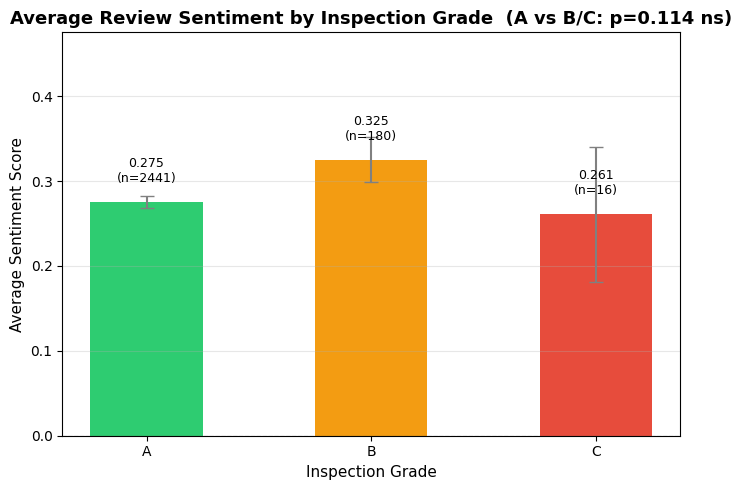

In [56]:
# Statistical test: A vs B+C
a_scores = merged[merged['grade'] == 'A']['sentiment'].values
bc_scores = merged[merged['grade'].isin(['B', 'C'])]['sentiment'].values

if len(bc_scores) > 0:
    u_stat, p_val = stats.mannwhitneyu(a_scores, bc_scores, alternative='two-sided')
    # Cohen's d
    d = (a_scores.mean() - bc_scores.mean()) / np.sqrt((a_scores.var() + bc_scores.var()) / 2)
    print(f'Mann-Whitney U: U={u_stat:.0f}, p={p_val:.4f}')
    print(f"Cohen's d: {d:.3f}  (|d|<0.2 negligible, 0.2-0.5 small, 0.5-0.8 medium, >0.8 large)")
else:
    p_val, d = None, None
    print('No B/C restaurants matched - cannot run significance test')

avg_sent = merged.groupby('grade')['sentiment'].agg(['mean', 'sem', 'count']).reindex(GRADE_ORDER)
print('\nGrade means:')
print(avg_sent.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    GRADE_ORDER,
    avg_sent['mean'],
    yerr=avg_sent['sem'],
    color=[GRADE_COLORS[g] for g in GRADE_ORDER],
    width=0.5,
    capsize=5,
    error_kw={'elinewidth': 1.5, 'ecolor': 'gray'},
)
for bar, g, n in zip(bars, GRADE_ORDER, avg_sent['count']):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
            f'{h:.3f}\n(n={int(n)})', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Inspection Grade')
ax.set_ylabel('Average Sentiment Score')
title = 'Average Review Sentiment by Inspection Grade'
if p_val is not None:
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    title += f'  (A vs B/C: p={p_val:.3g} {sig})'
ax.set_title(title, fontweight='bold')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylim(min(0, avg_sent['mean'].min() - 0.1), avg_sent['mean'].max() + 0.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('q3_fig2_avg_sentiment_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Average sentiment is nearly identical across all three grades (A: 0.275, B: 0.325, C: 0.261), and the difference between A and B/C is not statistically significant (p = 0.114). Counterintuitively, Grade B scores highest — not Grade A. This suggests public review language does not reliably track official inspection outcomes, indicating diners may not perceive the hygiene issues that inspectors flag.

### Fig 3 — Sentiment vs Inspection Score (scatter + trend line)

Pearson r  = 0.048  (p=0.0128)
Spearman r = 0.046  (p=0.0193)


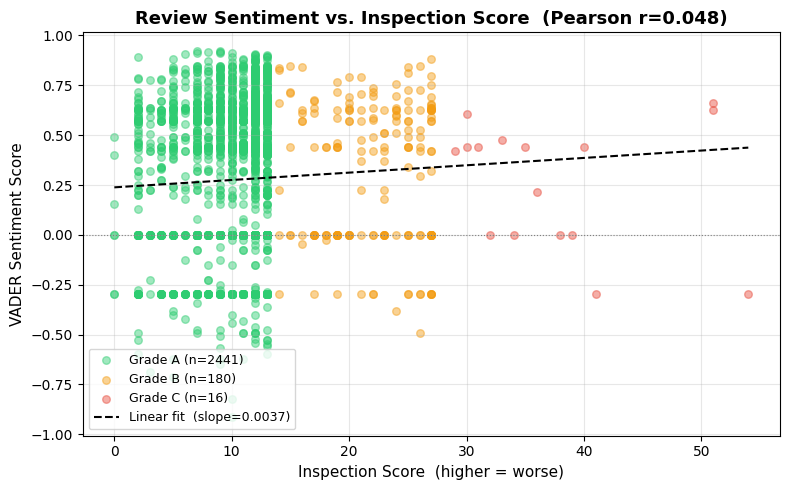

In [57]:
merged_scored = merged.dropna(subset=['insp_score']).copy()
merged_scored = merged_scored[merged_scored['insp_score'].between(0, 150)]

# Correlations
pearson_r, pearson_p = stats.pearsonr(merged_scored['insp_score'], merged_scored['sentiment'])
spearman_r, spearman_p = stats.spearmanr(merged_scored['insp_score'], merged_scored['sentiment'])
print(f'Pearson r  = {pearson_r:.3f}  (p={pearson_p:.3g})')
print(f'Spearman r = {spearman_r:.3f}  (p={spearman_p:.3g})')

fig, ax = plt.subplots(figsize=(8, 5))
for g in GRADE_ORDER:
    sub = merged_scored[merged_scored['grade'] == g]
    ax.scatter(sub['insp_score'], sub['sentiment'],
               color=GRADE_COLORS[g], alpha=0.45, s=30, label=f'Grade {g} (n={len(sub)})')

# Trend line
x = merged_scored['insp_score'].values
y = merged_scored['sentiment'].values
m, b = np.polyfit(x, y, 1)
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, m * xline + b, color='black', linewidth=1.5, linestyle='--',
        label=f'Linear fit  (slope={m:.4f})')

ax.set_xlabel('Inspection Score  (higher = worse)')
ax.set_ylabel('VADER Sentiment Score')
ax.set_title(f'Review Sentiment vs. Inspection Score  (Pearson r={pearson_r:.3f})', fontweight='bold')
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('q3_fig3_sentiment_vs_score_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

The correlation between review sentiment and inspection score is extremely weak (Pearson r = 0.048, Spearman r = 0.046). Though the p-values are technically significant due to the large sample size (p ≈ 0.01–0.02), the effect size is negligible — the trend line is nearly flat. Interestingly, the slope is slightly positive, meaning restaurants with worse inspection scores tend to have marginally more positive reviews, the opposite of what we might expect. This reinforces the finding from Fig 2: public sentiment and official hygiene evaluations operate on largely independent dimensions.

### Fig 4 — Borough × Grade heatmap (addresses teammate's question)

Mean sentiment by borough × grade:
grade              A      B      C
borough                           
Manhattan      0.299  0.328  0.261
Brooklyn       0.235  0.351    NaN
Queens         0.152  0.285    NaN
Bronx          0.159  0.238    NaN
Staten Island  0.168  0.493    NaN


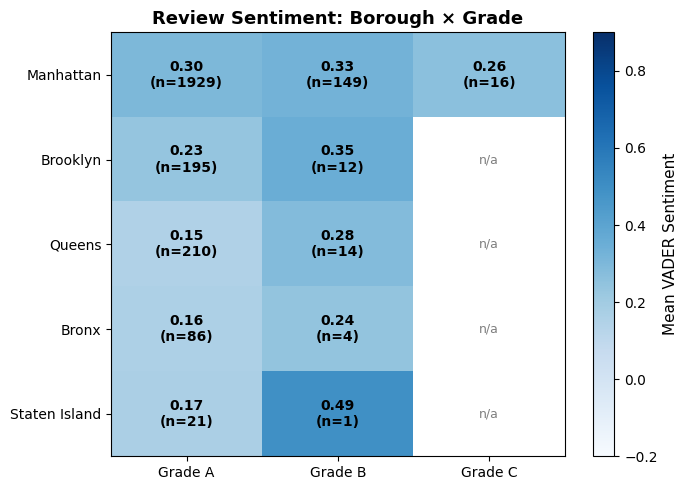

In [58]:
# Pivot table: borough × grade → mean sentiment
heatmap = (
    merged.groupby(['borough', 'grade'])['sentiment']
    .mean().unstack('grade')
    .reindex(columns=GRADE_ORDER)
)
# Borough order
boro_order = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']
heatmap = heatmap.reindex([b for b in boro_order if b in heatmap.index])
print('Mean sentiment by borough × grade:')
print(heatmap.round(3))

# Also show counts for transparency
counts = (
    merged.groupby(['borough', 'grade']).size().unstack('grade')
    .reindex(columns=GRADE_ORDER).fillna(0).astype(int)
)
counts = counts.reindex([b for b in boro_order if b in counts.index])

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(heatmap.values, cmap='Blues', aspect='auto', vmin=-0.2, vmax=0.9)

ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels([f'Grade {c}' for c in heatmap.columns])
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index)

# Annotate with sentiment + count
for i in range(len(heatmap.index)):
    for j in range(len(heatmap.columns)):
        val = heatmap.values[i, j]
        n = counts.values[i, j]
        if pd.notna(val):
            ax.text(j, i, f'{val:.2f}\n(n={n})', ha='center', va='center',
                    color='black', fontsize=10, fontweight='bold')
        else:
            ax.text(j, i, 'n/a', ha='center', va='center', color='gray', fontsize=9)

plt.colorbar(im, ax=ax, label='Mean VADER Sentiment')
ax.set_title('Review Sentiment: Borough × Grade', fontweight='bold')
plt.tight_layout()
plt.savefig('q3_fig4_borough_grade_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Manhattan shows the highest Grade A sentiment (0.30) while Queens and the Bronx sit noticeably lower (0.15–0.16), despite all holding the same A grade. Interestingly, within every borough that has both A and B data, Grade B sentiment is higher than Grade A sentiment — the opposite of what inspection scores would predict. This cross-borough consistency of the inversion suggests the pattern is not random noise but points to a systematic disconnect between hygiene-based grading and diner-perceived experience. The Bronx's elevated violation rates (from Q2) are not reflected in more negative reviews, supporting the team's earlier hypothesis.

### Fig 5 — Top words: Grade A vs Grade B/C

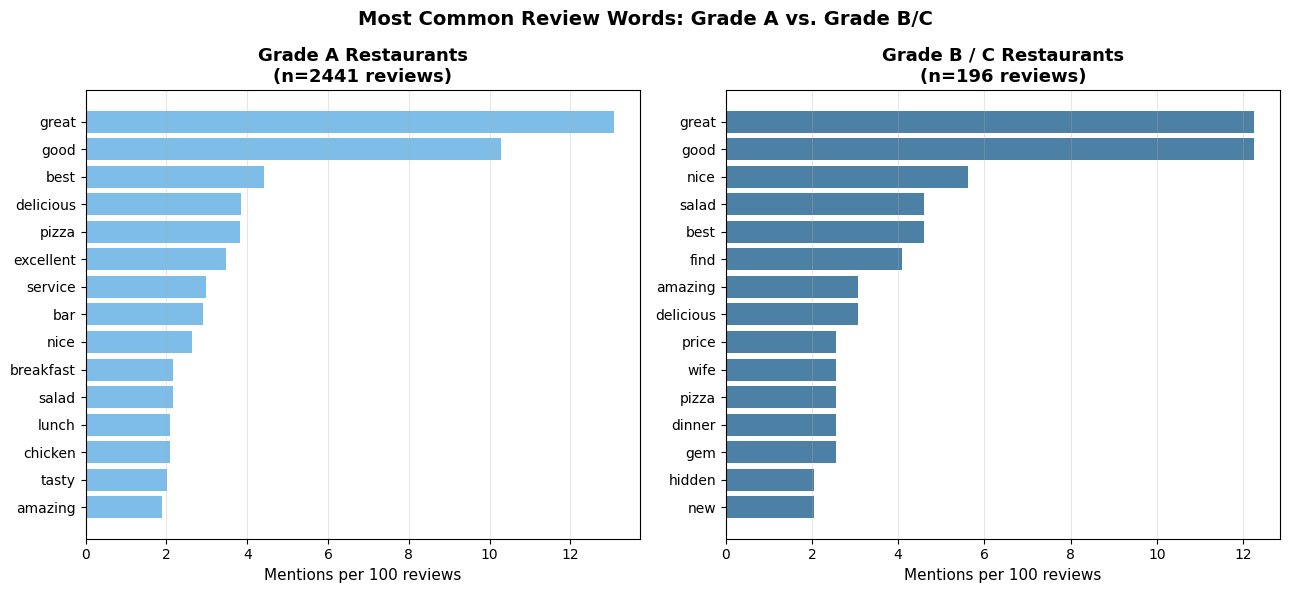

In [59]:
STOPWORDS = {
    'the','a','an','and','or','but','is','was','were','it','its','in','on',
    'at','to','for','of','with','this','that','we','i','my','our','they',
    'he','she','had','have','has','be','been','are','as','so','by','from',
    'not','no','very','also','just','food','restaurant','place','came','went',
    'got','get','go','us','their','there','here','one','all','more','would',
    'will','like','out','up','about','really','well',
    'time','back','did','do','even','made','make','menu','you','your',
}

def top_words(texts, n=15):
    words = []
    for text in texts:
        tokens = re.findall(r'[a-z]+', str(text).lower())
        words.extend([w for w in tokens if w not in STOPWORDS and len(w) > 2])
    return Counter(words).most_common(n)

grade_a = merged[merged['grade'] == 'A']['comment'].tolist()
grade_bc = merged[merged['grade'].isin(['B', 'C'])]['comment'].tolist()

top_a  = top_words(grade_a, 15)
top_bc = top_words(grade_bc, 15)

# Normalize: mentions per 100 reviews
def normalize(words, n_docs):
    return [(w, c / n_docs * 100) for w, c in words]

top_a_norm  = normalize(top_a, len(grade_a))
top_bc_norm = normalize(top_bc, max(1, len(grade_bc)))

fig, (ax_a, ax_bc) = plt.subplots(1, 2, figsize=(13, 6))

words_a, vals_a = zip(*top_a_norm) if top_a_norm else ([], [])
ax_a.barh(words_a[::-1], vals_a[::-1], color='#5dade2', alpha=0.8)
ax_a.set_title(f'Grade A Restaurants\n(n={len(grade_a)} reviews)', fontweight='bold')
ax_a.set_xlabel('Mentions per 100 reviews')
ax_a.grid(axis='x', alpha=0.3)

if top_bc_norm:
    words_bc, vals_bc = zip(*top_bc_norm)
    ax_bc.barh(words_bc[::-1], vals_bc[::-1], color='#1f618d', alpha=0.8)
ax_bc.set_title(f'Grade B / C Restaurants\n(n={len(grade_bc)} reviews)', fontweight='bold')
ax_bc.set_xlabel('Mentions per 100 reviews')
ax_bc.grid(axis='x', alpha=0.3)

fig.suptitle('Most Common Review Words: Grade A vs. Grade B/C', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('q3_fig5_word_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

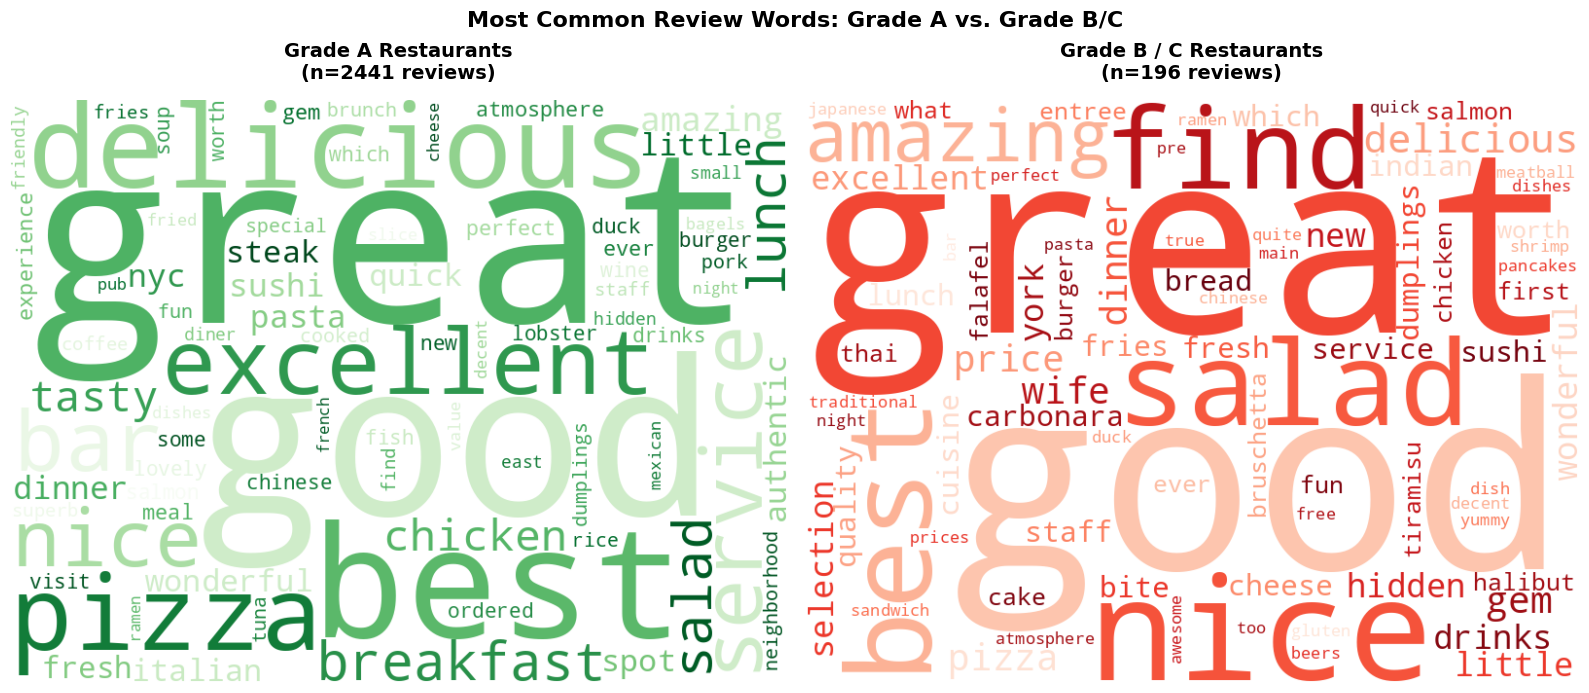

In [60]:
# === Fig 5 (Word Cloud version) ===
# Install wordcloud first if needed:
# !pip install wordcloud -q

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import re

STOPWORDS = {
    'the','a','an','and','or','but','is','was','were','it','its','in','on',
    'at','to','for','of','with','this','that','we','i','my','our','they',
    'he','she','had','have','has','be','been','are','as','so','by','from',
    'not','no','very','also','just','food','restaurant','place','came','went',
    'got','get','go','us','their','there','here','one','all','more','would',
    'will','like','out','up','about','really','well',
    'time','back','did','do','even','made','make','menu','you','your',
}

def get_word_freq(texts):
    words = []
    for text in texts:
        tokens = re.findall(r'[a-z]+', str(text).lower())
        words.extend([w for w in tokens if w not in STOPWORDS and len(w) > 2])
    return dict(Counter(words))

grade_a_texts = merged[merged['grade'] == 'A']['comment'].tolist()
grade_bc_texts = merged[merged['grade'].isin(['B', 'C'])]['comment'].tolist()

freq_a = get_word_freq(grade_a_texts)
freq_bc = get_word_freq(grade_bc_texts)

# Word cloud config
wc_a = WordCloud(
    width=800, height=600,
    background_color='white',
    colormap='Greens',
    max_words=80,
    relative_scaling=0.5,
    min_font_size=12,
    prefer_horizontal=0.9,
    random_state=42,
).generate_from_frequencies(freq_a)

wc_bc = WordCloud(
    width=800, height=600,
    background_color='white',
    colormap='Reds',
    max_words=80,
    relative_scaling=0.5,
    min_font_size=12,
    prefer_horizontal=0.9,
    random_state=42,
).generate_from_frequencies(freq_bc)

# Plot side by side
fig, (ax_a, ax_bc) = plt.subplots(1, 2, figsize=(16, 7))

ax_a.imshow(wc_a, interpolation='bilinear')
ax_a.axis('off')
ax_a.set_title(f'Grade A Restaurants\n(n={len(grade_a_texts)} reviews)',
               fontsize=14, fontweight='bold', pad=15)

ax_bc.imshow(wc_bc, interpolation='bilinear')
ax_bc.axis('off')
ax_bc.set_title(f'Grade B / C Restaurants\n(n={len(grade_bc_texts)} reviews)',
                fontsize=14, fontweight='bold', pad=15)

fig.suptitle('Most Common Review Words: Grade A vs. Grade B/C',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q3_fig5_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

Both groups share the same top words — "great", "good", "best", "delicious", "nice" — dominate in reviews of A and B/C restaurants alike. No negative or hygiene-related terms (e.g. "dirty", "rude", "wait") appear in either top-15 list. Interestingly, Grade B/C reviews uniquely feature words like "find", "gem", "hidden", and "new", suggesting these restaurants are framed as discoveries rather than flawed establishments. The overwhelming similarity in review language across grades reinforces the conclusion that public reviews do not linguistically distinguish restaurants by inspection outcome — diners praise food, service, and atmosphere regardless of the underlying hygiene rating.

Summary statistics & export

Save the merged dataframe for use in Streamlit / further analysis.

In [61]:
print('=== Summary ===')
print(f'Matched restaurants:      {len(merged):,}')
print(f'Match rate:               {len(merged) / len(ta):.1%}')
print(f'Boroughs covered:         {merged["borough"].nunique()} / 5')
print()
print('Sentiment by grade:')
print(merged.groupby('grade')['sentiment'].describe().round(3))
print()
if p_val is not None:
    print(f'A vs B/C Mann-Whitney U:  p = {p_val:.4g}')
    print(f"Cohen's d:                  {d:.3f}")
print(f'Pearson r (sent vs score): {pearson_r:.3f}  (p={pearson_p:.3g})')

# Export merged data
out_path = '/content/drive/MyDrive/claude_workspace/q3_merged_data.csv'
merged.to_csv(out_path, index=False)
print(f'\nMerged data saved to: {out_path}')
print('Figures saved to /content/ (download from the Files panel on the left)')

=== Summary ===
Matched restaurants:      2,637
Match rate:               25.4%
Boroughs covered:         5 / 5

Sentiment by grade:
        count   mean    std    min  25%    50%    75%    max
grade                                                       
A      2441.0  0.275  0.373 -0.915  0.0  0.420  0.612  0.924
B       180.0  0.325  0.351 -0.494  0.0  0.440  0.625  0.881
C        16.0  0.261  0.317 -0.296  0.0  0.431  0.449  0.659

A vs B/C Mann-Whitney U:  p = 0.1144
Cohen's d:                  -0.124
Pearson r (sent vs score): 0.048  (p=0.0128)

Merged data saved to: /content/drive/MyDrive/claude_workspace/q3_merged_data.csv
Figures saved to /content/ (download from the Files panel on the left)


In [64]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/Final Q3.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Final Q3.ipynb to html
[NbConvertApp] Writing 283934 bytes to /content/drive/MyDrive/Colab Notebooks/Final Q3.html


In [63]:
from google.colab import _message
nb = _message.blocking_request('get_ipynb', timeout_sec=30)
print("Notebook has", len(nb['ipynb']['cells']), "cells")

Notebook has 38 cells
